# Iris Flower Classification using Machine Learning 
This project classifies iris flowers into three species using ML models.

### Data Preprocessing

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [81]:
## 📊 Dataset Description

# Total Samples: 150  
# Features: Sepal Length, Sepal Width, Petal Length, Petal Width  
# Classes: Setosa, Versicolor, Virginica  

iris = load_iris()
X=iris.data
y=iris.target

df=pd.DataFrame(X,columns=iris.feature_names)
df['target']=y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [22]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


In [23]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int32  
dtypes: float64(4), int32(1)
memory usage: 5.4 KB


In [25]:
df.size

750

In [26]:
df.shape

(150, 5)

In [27]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [28]:
df.isna()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [60]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

In [61]:
# Map target numbers to names
df['species'] = df['target'].map({
    0: 'Setosa',
    1: 'Versicolor',
    2: 'Virginica'
})

# Style
sns.set(style="whitegrid")

### Exploratory Data Analysis (EDA)

We visualize relationships between features to understand class separability.

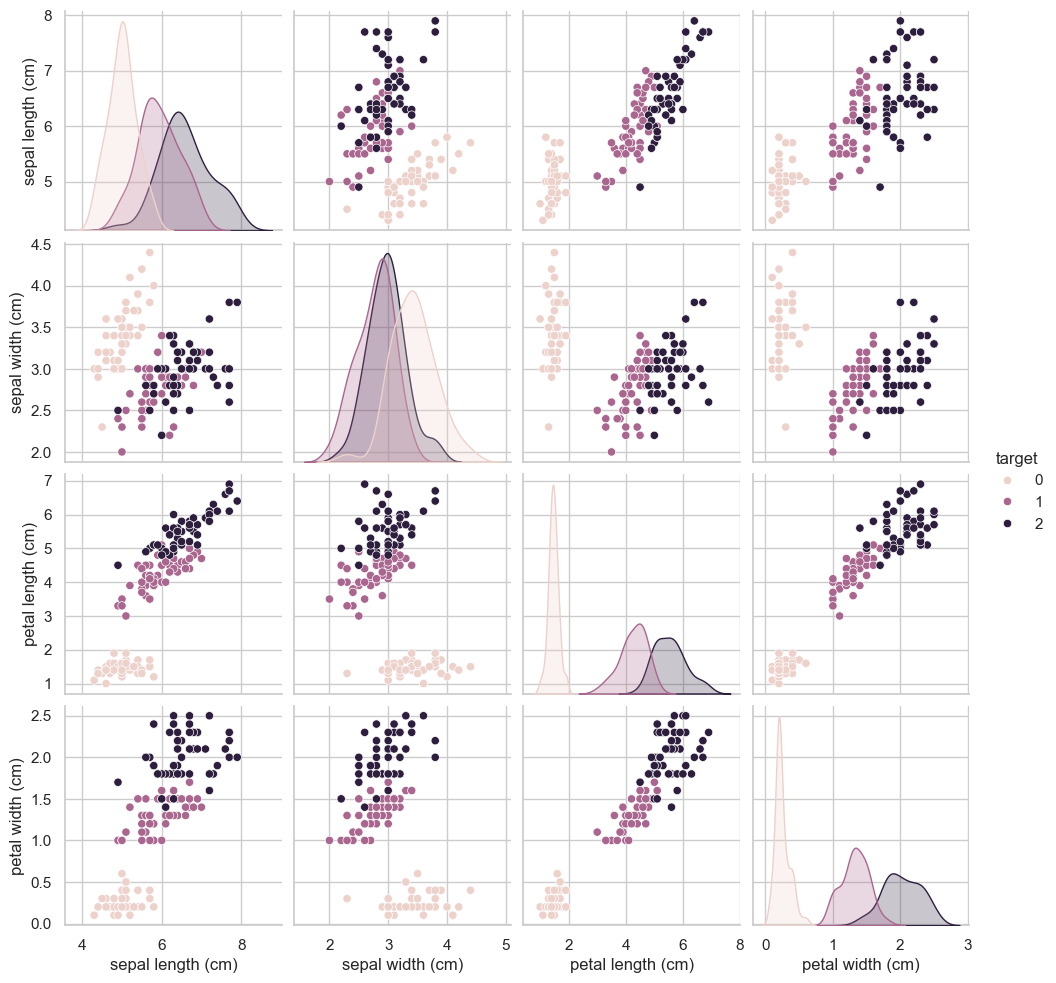

In [82]:
# -----------
# Pair Plot 
# ------------
plt.show()
sns.pairplot(df, hue='target')
plt.show()

### Observation:
- Petal features show clear separation
- Setosa is easily distinguishable

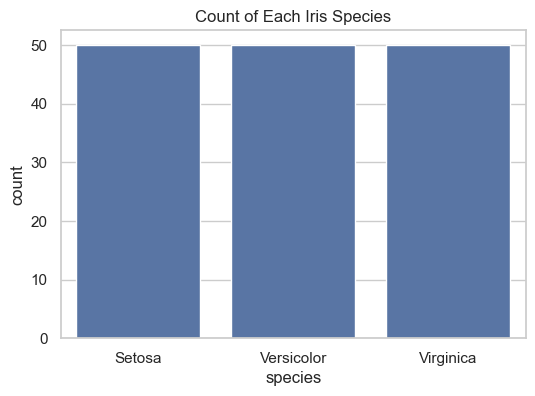

In [64]:
# -------------------------------
# Count Plot
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='species', data=df)
plt.title("Count of Each Iris Species")
plt.show()

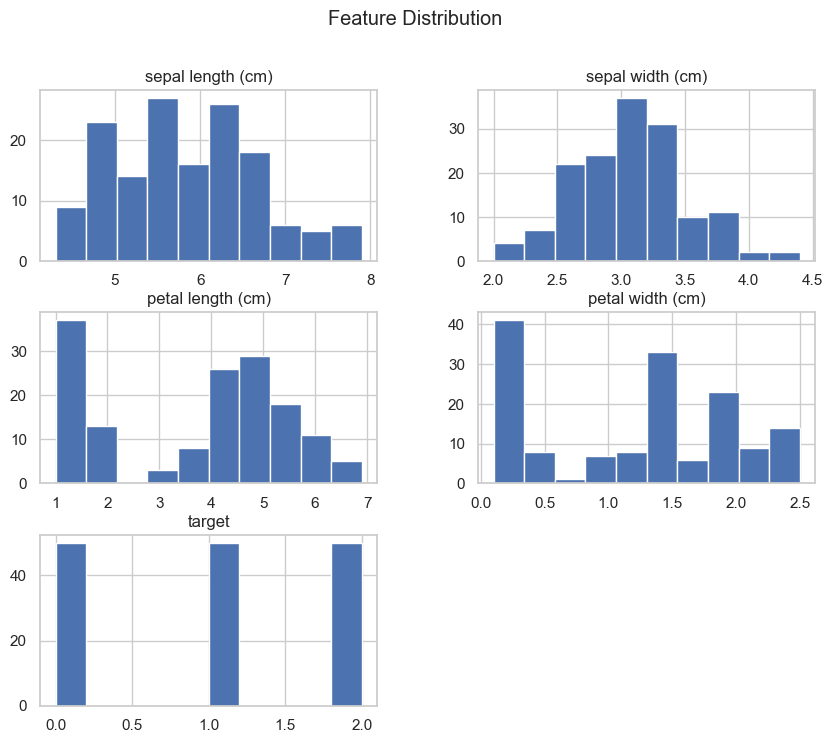

In [65]:
# -------------------------------
# Histograms
# -------------------------------
df.hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

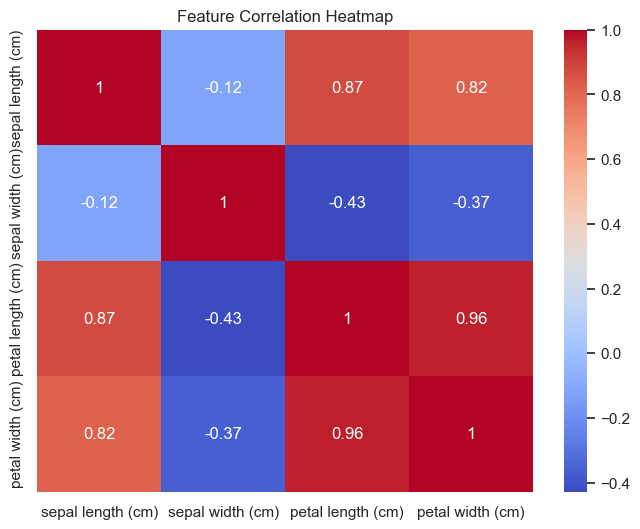

In [66]:
# -------------------------------
# Heatmap (Correlation)
# -------------------------------
plt.figure(figsize=(8,6))
corr = df.iloc[:, :-2].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


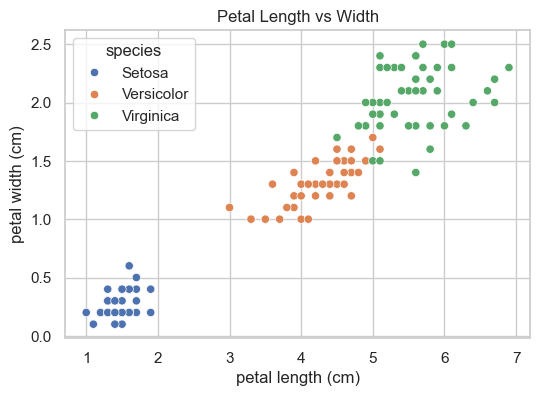

In [67]:
# -------------------------------
# Scatter Plot (Important)
# -------------------------------
plt.figure(figsize=(6,4))
sns.scatterplot(x='petal length (cm)', y='petal width (cm)', hue='species', data=df)
plt.title("Petal Length vs Width")
plt.show()

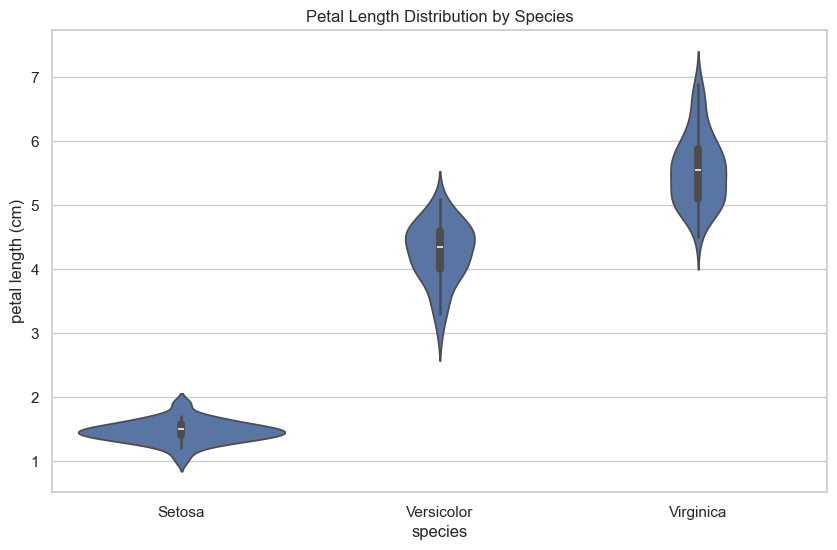

In [68]:
# -------------------------------
# Violin Plot
# -------------------------------
plt.figure(figsize=(10,6))
sns.violinplot(x='species', y='petal length (cm)', data=df)
plt.title("Petal Length Distribution by Species")
plt.show()

## Data Splitting

The dataset is divided into training and testing sets (80-20 split).

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
# ==============================
# Train KNN Model
# ==============================

# KNN - KNN classifies based on nearest neighbors.

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

# ==============================
# Train Random Forest Model
# ==============================

# Random Forest - Ensemble model combining multiple trees to reduce overfitting.

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ==============================
# Train SVM Model
# ==============================

# SVM - separates classes using optimal hyperplanes.

svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

#### 📊 Model Performance

All models achieved 100% accuracy on test data.
However, cross-validation gives a more realistic performance.

In [71]:
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

KNN Accuracy: 1.0
Random Forest Accuracy: 1.0
SVM Accuracy: 1.0


In [85]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Accuracy:", scores.mean())

Cross Validation Accuracy: 0.96


In [73]:
from sklearn.model_selection import cross_val_score

print(f"KNN CV: {cross_val_score(knn, X, y, cv=5).mean():.2f}")
print(f"RF CV: {cross_val_score(rf, X, y, cv=5).mean():.2f}")
print(f"SVM CV: {cross_val_score(svm, X, y, cv=5).mean():.2f}")

KNN CV: 0.97
RF CV: 0.96
SVM CV: 0.97


### Final Insight:
- Test Accuracy = 100%
- Cross Validation ≈ 96%
- Model shows strong generalization

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



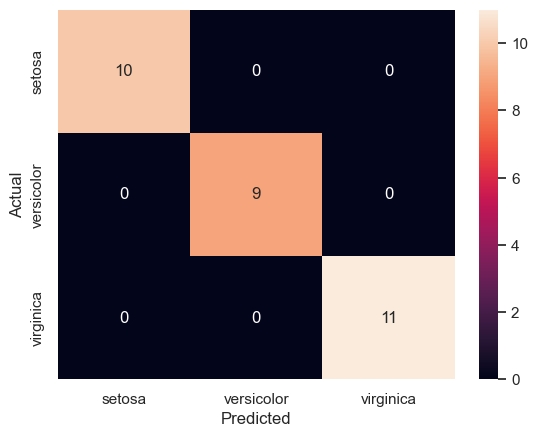

In [86]:
print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

 ## Prediction System

Model can predict species for new input values.

In [79]:
sample = [[1.1, 3.5, 3.4, 5.2]]
prediction = svm.predict(sample)

print("Predicted Class:", iris.target_names[prediction][0])

Predicted Class: virginica


## Conclusion

- Petal features are most important
- Random Forest and SVM performed best
- Cross-validation shows ~96% accuracy
- Dataset is clean and easy to classify

#### This project demonstrates a complete machine learning workflow including EDA, model training, evaluation, and prediction.